# Détection Alzheimer avec IRM via Deep Learning

## Objectifs
- Charger des images IRM
- Préparer les données
- Construire un modèle CNN simple
- Entraîner le modèle
- Évaluer les performances
- Tester une nouvelle image



# 1. Import

In [1]:
import tensorflow as tf
import os
import cv2
import imghdr
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

C:\Users\Magalie\AppData\Local\Temp\ipykernel_15732\2353109687.py:4: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


## 2. Nettoyage des images

In [2]:
data_dir = 'data'
image_extentions_to_keep = ['jpeg','jpg', 'bmp', 'png']


for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_extentions_to_keep:
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))

## 3. Chargement du dataset

In [3]:
data = tf.keras.utils.image_dataset_from_directory(
    "data",                   
    image_size=(128,128),       
    color_mode="grayscale",    
    batch_size=32,
    shuffle=True,             
    seed=42
)

Found 16064 files belonging to 2 classes.


## 4. Vérification des données (format)

In [4]:
for x, y in data.take(1):
    print(x.shape, y.shape)

(32, 128, 128, 1) (32,)


## 5. Visualisation


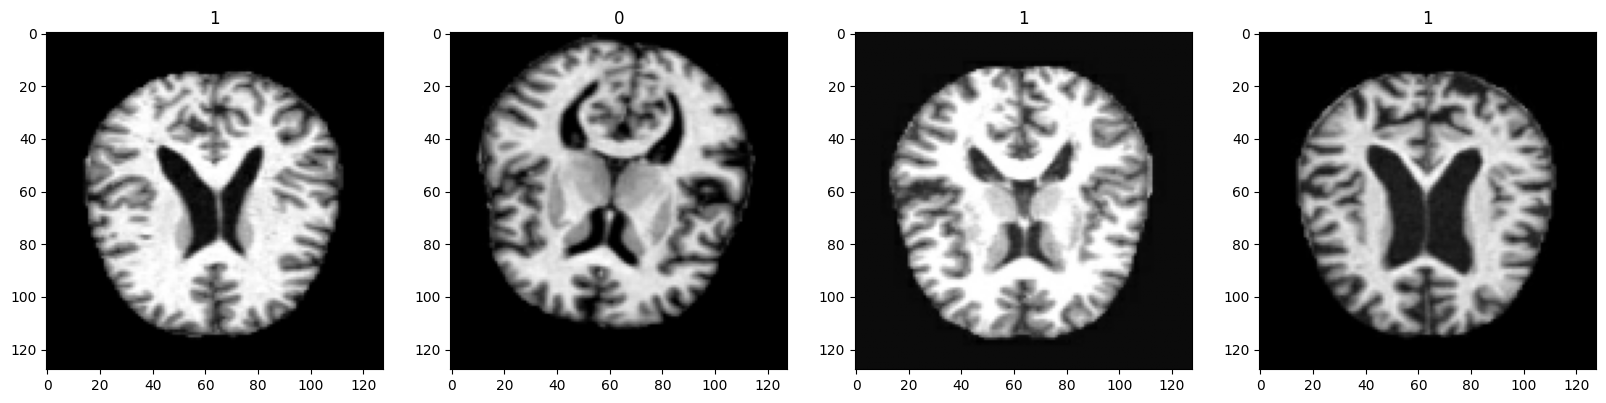

In [6]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][5:9]):
    ax[idx].imshow(img.squeeze(), cmap='gray')
    ax[idx].title.set_text(batch[1][idx])

## 6. Normalisation

In [15]:
data = data.map(lambda x, y: (x/255.0, y))

## 7. Séparation des données

In [16]:
dataset_size = len(data)

train_size = int(dataset_size * 0.7)
val_size   = int(dataset_size * 0.2)
test_size  = int(dataset_size * 0.1)

train = data.take(train_size)
val   = data.skip(train_size).take(val_size)
test  = data.skip(train_size + val_size).take(test_size)

## 8. Import du modèle CNN
On prépare les couches nécessaires au réseau de neurones.

In [17]:
# Création du modèle CNN
model = Sequential([
    Input((128,128,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

## 9. Construction du modèle

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,345 (14.13 MB)

 Trainable params: 3,705,345 (14.13 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Entraînement du modèle

In [19]:
# Lancement de l'entraînement
history = model.fit(train, epochs=30, validation_data=val)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 213ms/step - accuracy: 0.8854 - loss: 0.2533 - val_accuracy: 0.9759 - val_loss: 0.0653
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 216ms/step - accuracy: 0.9762 - loss: 0.0635 - val_accuracy: 0.9900 - val_loss: 0.0301
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.9898 - loss: 0.0292 - val_accuracy: 0.9916 - val_loss: 0.0271
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 214ms/step - accuracy: 0.9960 - loss: 0.0129 - val_accuracy: 0.9956 - val_loss: 0.0131
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 217ms/step - accuracy: 0.9955 - loss: 0.0117 - val_accuracy: 0.9959 - val_loss: 0.0133
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 208ms/step - accuracy: 0.9948 - loss: 0.0130 - val_accuracy: 0.9875 - val_loss: 0.0320
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 293ms/step - accuracy: 0.9972 - loss: 0.0098 - val_accuracy: 0.9856 - val_loss: 0.0395
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 244ms/step - accuracy: 0.9976 - loss: 

## 11. Courbe de perte

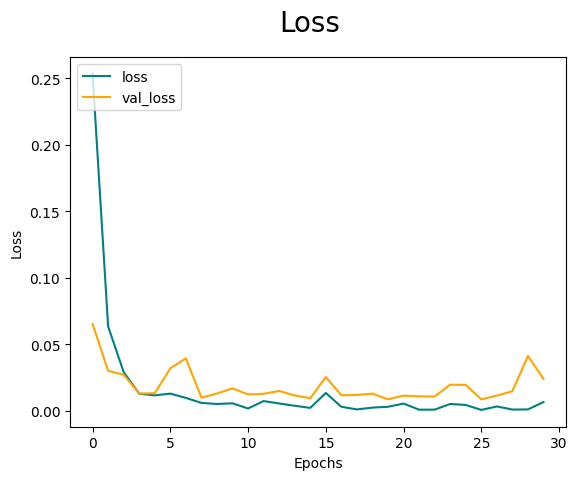

In [20]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper left")
plt.show()

## 12. Model Accuracy Progress

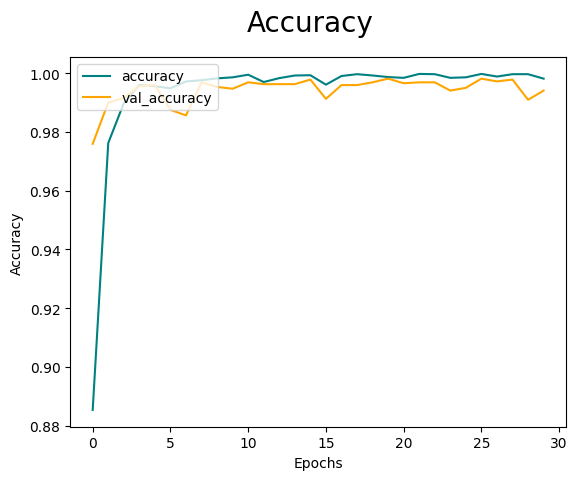

In [21]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc="upper left")
plt.show()

## 13. Initialisation des métriques
Préparation des outils de mesure.

In [22]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

## 14. Test du modèle

In [23]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━

## 15. Résultats
Affichage des performances finales.

In [24]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(0.9989189, shape=(), dtype=float32) tf.Tensor(0.98612595, shape=(), dtype=float32) tf.Tensor(0.99125, shape=(), dtype=float32)


## 16. Sauvegarde du modèle

In [25]:
model.save("modele_alzheimer.keras")

## 17. Chargement du modèle

In [28]:
model = load_model("modele_alzheimer.keras")


## 18. Chargement d’une image test

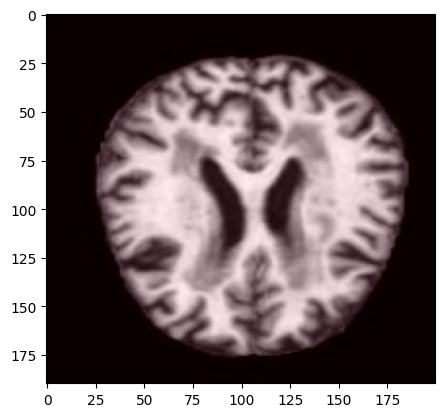

In [29]:
img = cv2.imread('test.jpg')
plt.imshow(img)
plt.show()

## 19. Prétraitement de l’image
Redimensionnement et normalisation de l’image.

In [30]:
img = cv2.imread("test.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128,128))
img = img / 255.0
img = img.reshape(1,128,128,1)


## 20. Prédiction
Le modèle prédit la classe de l’image.

In [31]:

yhat = model.predict(img)
yhat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[0.9999929]], dtype=float32)

## 21. Interprétation
Affichage du résultat final.

In [33]:
if yhat > 0.5:
    print(f'Predicted class is Alz')
else:
    print(f'Predicted class is Sain')

Predicted class is Alz
